# Reward-Value Decoding — Whole-Brain + ROI Group Results

RidgeCV, leave-one-run-out CV, continuous target = objective reward level of the first
stimulus (`first_stim_value`, integers 1–5; source: BBT). Four masks: whole-brain,
visual cortex (Harvard-Oxford), vmPFC and striatum (Bartra et al. 2013 meta-analytic ROIs).

Metric: Pearson `r` between cross-validated predictions and true reward level (null = 0),
plus `r²` for reference. **`r`/`r²` here are run-demeaned** (both true and predicted
values demeaned by their own run's mean before correlating) — see the status note below
for why; raw (non-demeaned) numbers are also loaded as `r_raw`/`r2_raw` for comparison.
This is the "plain decoding" baseline — no spatial map — from `run_qvalue_decoding.py`,
alongside the eventual `searchlight_results.ipynb`/`frem_results.ipynb` reward-value
counterparts.

**Status (2026-08-07):** the first full-cohort run (58/59 subjects; `sub-46` is absent
from the BBT entirely, not one of the known second-level exclusions
`sub-44/48/68/17/31` — flagged, not worked around) showed a significant *negative* `r`
for vmPFC/striatum. Decomposing `r` into between-run (3 points/subject) vs within-run
components showed the between-run component was strongly negative for **every** mask
(−0.46 to −0.92) — a `LeaveOneGroupOut` CV arithmetic artifact: reward level is ~flat
across runs by design (levels `{1,2,2,3,3,4,4,5}` average to exactly 3.0), so with only
3 folds a heavily-regularized model's prediction sits near the training-fold mean, which
is mechanically anti-correlated with the held-out run's mean. It dominated vmPFC/striatum
(little real within-run signal to outweigh it — those ROIs are only ~120 voxels) but was
silently present, just outweighed, for wholebrain/visual cortex too.

`run_qvalue_decoding.py` now (a) run-demeans features before fitting (removes
session-level drift as a nuisance confound, leakage-safe since it only uses `run`
membership, never `y`) and (b) scores `r`/`r2` on run-demeaned true/predicted values
(a post-hoc scoring transform, doesn't feed back into fitting) — isolating the
within-run relationship the analysis actually cares about. This notebook reflects the
rerun with that fix.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

DATA_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives/decoding")
TAG = "reward"   # filename tag for target_col='first_stim_value' (see run_qvalue_decoding.py)
MASKS = ["wholebrain", "visualcortex", "vmpfc", "striatum"]
MASK_LABELS = {"wholebrain": "Whole brain", "visualcortex": "Visual cortex",
               "vmpfc": "vmPFC", "striatum": "Striatum"}
COLORS = {"wholebrain": "#4C72B0", "visualcortex": "#DD8452",
          "vmpfc": "#55A868", "striatum": "#C44E52"}
NULL_R = 0.0

In [2]:
records = []
pred_frames = []

for sub_dir in sorted(DATA_DIR.glob("sub-*")):
    sub_id = sub_dir.name.replace("sub-", "")
    summary_file = sub_dir / f"sub-{sub_id}_qvalue_decoding_{TAG}.csv"
    pred_file = sub_dir / f"sub-{sub_id}_qvalue_decoding_predictions_{TAG}.csv"
    if not summary_file.exists():
        continue

    summary = pd.read_csv(summary_file)
    summary.insert(0, "subject", sub_id)
    records.append(summary)

    if pred_file.exists():
        preds = pd.read_csv(pred_file)
        preds.insert(0, "subject", sub_id)
        pred_frames.append(preds)

df = (pd.concat(records, ignore_index=True) if records
      else pd.DataFrame(columns=["subject", "mask", "n_voxels", "r", "r2", "r_raw", "r2_raw", "n_trials"]))
preds_df = (pd.concat(pred_frames, ignore_index=True) if pred_frames
            else pd.DataFrame(columns=["subject", "mask", "run", "y_true", "y_pred"]))

n_subjects = df["subject"].nunique()
print(f"{n_subjects} subject(s) loaded, masks: {sorted(df['mask'].unique()) if n_subjects else []}")

58 subject(s) loaded, masks: ['striatum', 'visualcortex', 'vmpfc', 'wholebrain']


## Group r / r²

wholebrain: mean r=0.099, t(57)=9.39, p=3.57e-13  ***
visualcortex: mean r=0.214, t(57)=15.42, p=5.41e-22  ***
vmpfc: mean r=-0.024, t(57)=-2.96, p=4.46e-03  **
striatum: mean r=-0.022, t(57)=-2.23, p=2.95e-02  *


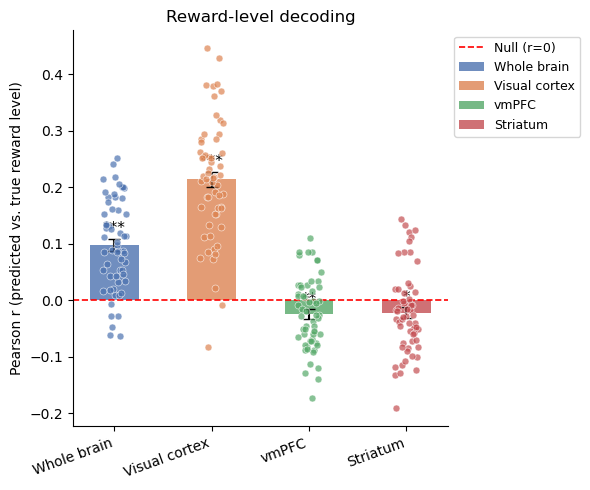

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))

x = np.arange(len(MASKS))
w = 0.5

for i, mask in enumerate(MASKS):
    vals = df.loc[df["mask"] == mask, "r"].values
    if len(vals) == 0:
        continue
    color = COLORS[mask]
    ax.bar(i, vals.mean(), width=w, color=color, alpha=0.8, label=MASK_LABELS[mask], zorder=2)
    if len(vals) > 1:
        ax.errorbar(i, vals.mean(), yerr=vals.std() / np.sqrt(len(vals)),
                    fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)
    jitter = np.random.default_rng(0).uniform(-0.12, 0.12, len(vals))
    ax.scatter(i + jitter, vals, color=color, edgecolors='white',
               linewidth=0.5, s=25, alpha=0.7, zorder=4)

ax.axhline(NULL_R, color='red', linestyle='--', linewidth=1.2, label='Null (r=0)')
ax.set_xticks(x)
ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=20, ha='right')
ax.set_ylabel("Pearson r (predicted vs. true reward level)")
ax.set_title("Reward-level decoding")
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
ax.spines[['top', 'right']].set_visible(False)

for i, mask in enumerate(MASKS):
    vals = df.loc[df["mask"] == mask, "r"].values
    if len(vals) < 2:
        continue
    t, p = stats.ttest_1samp(vals, NULL_R)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(i, vals.mean() + vals.std()/np.sqrt(len(vals)) + 0.01, sig, ha='center', fontsize=11)
    print(f"{mask}: mean r={vals.mean():.3f}, t({len(vals)-1})={t:.2f}, p={p:.2e}  {sig}")

plt.tight_layout()
plt.show()

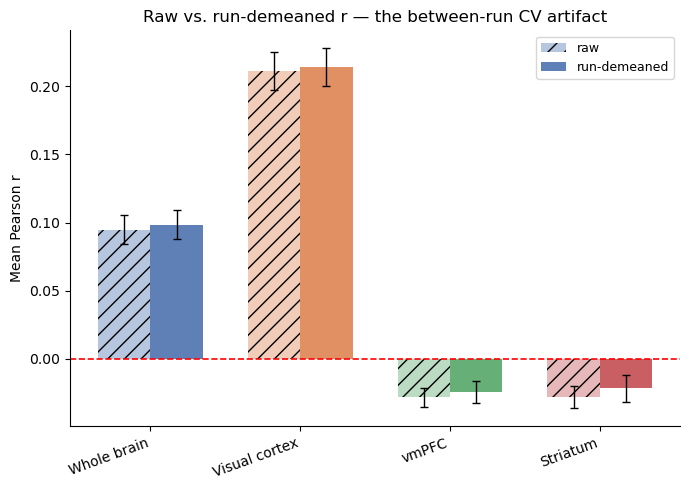

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(MASKS))
w = 0.35

for i, mask in enumerate(MASKS):
    color = COLORS[mask]
    vals_raw = df.loc[df["mask"] == mask, "r_raw"].values
    vals_dm  = df.loc[df["mask"] == mask, "r"].values
    ax.bar(i - w/2, vals_raw.mean(), width=w, color=color, alpha=0.4, zorder=2,
           label="raw" if i == 0 else None, hatch='//')
    ax.bar(i + w/2, vals_dm.mean(), width=w, color=color, alpha=0.9, zorder=2,
           label="run-demeaned" if i == 0 else None)
    if len(vals_raw) > 1:
        ax.errorbar(i - w/2, vals_raw.mean(), yerr=vals_raw.std()/np.sqrt(len(vals_raw)),
                    fmt='none', color='black', capsize=3, linewidth=1)
        ax.errorbar(i + w/2, vals_dm.mean(), yerr=vals_dm.std()/np.sqrt(len(vals_dm)),
                    fmt='none', color='black', capsize=3, linewidth=1)

ax.axhline(NULL_R, color='red', linestyle='--', linewidth=1.2)
ax.set_xticks(x)
ax.set_xticklabels([MASK_LABELS[m] for m in MASKS], rotation=20, ha='right')
ax.set_ylabel("Mean Pearson r")
ax.set_title("Raw vs. run-demeaned r — the between-run CV artifact")
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

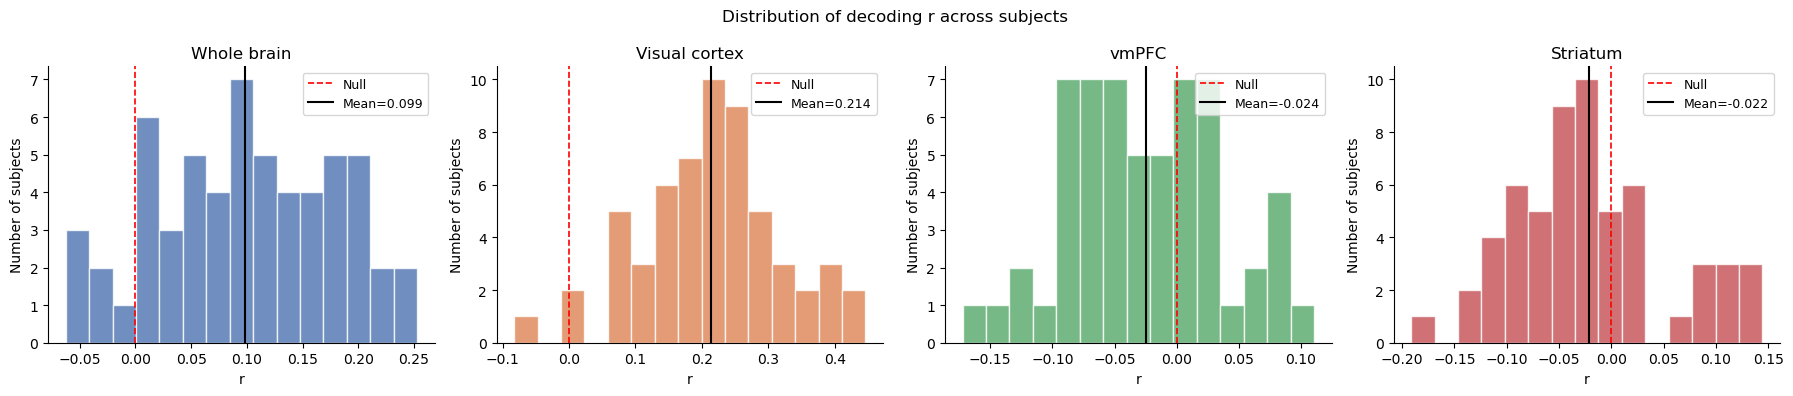

In [5]:
fig, axes = plt.subplots(1, len(MASKS), figsize=(4.5 * len(MASKS), 4), sharey=False)

for ax, mask in zip(axes, MASKS):
    vals = df.loc[df["mask"] == mask, "r"].values
    color = COLORS[mask]
    ax.hist(vals, bins=15, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(NULL_R, color='red', linestyle='--', linewidth=1.2, label='Null')
    if len(vals):
        ax.axvline(vals.mean(), color='black', linestyle='-', linewidth=1.5, label=f'Mean={vals.mean():.3f}')
    ax.set_xlabel("r")
    ax.set_ylabel("Number of subjects")
    ax.set_title(MASK_LABELS[mask])
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("Distribution of decoding r across subjects")
plt.tight_layout()
plt.show()

## Predicted vs. true reward level

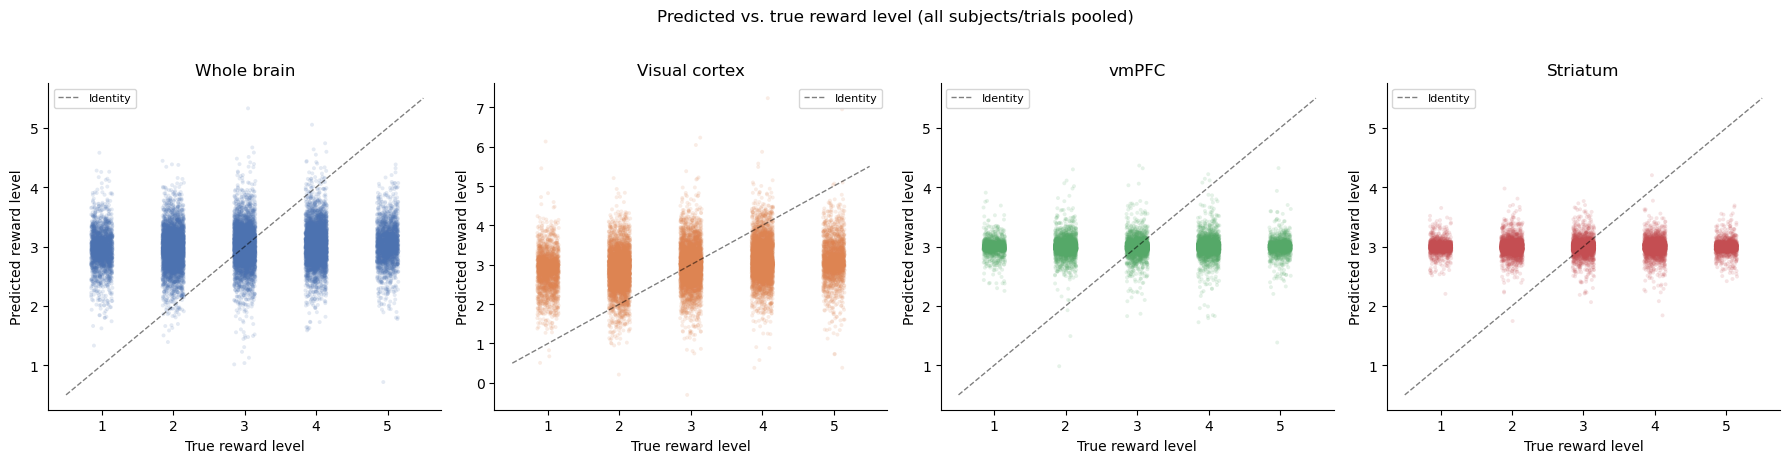

In [6]:
fig, axes = plt.subplots(1, len(MASKS), figsize=(4.5 * len(MASKS), 4.5))

for ax, mask in zip(axes, MASKS):
    sub = preds_df[preds_df["mask"] == mask]
    color = COLORS[mask]
    rng = np.random.default_rng(0)
    jitter_x = sub["y_true"] + rng.uniform(-0.15, 0.15, len(sub))
    ax.scatter(jitter_x, sub["y_pred"], color=color, alpha=0.15, s=8, edgecolors='none')
    if len(sub):
        lims = [sub["y_true"].min() - 0.5, sub["y_true"].max() + 0.5]
        ax.plot(lims, lims, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Identity')
    ax.set_xlabel("True reward level")
    ax.set_ylabel("Predicted reward level")
    ax.set_title(MASK_LABELS[mask])
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("Predicted vs. true reward level (all subjects/trials pooled)", y=1.02)
plt.tight_layout()
plt.show()

## Individual subject r

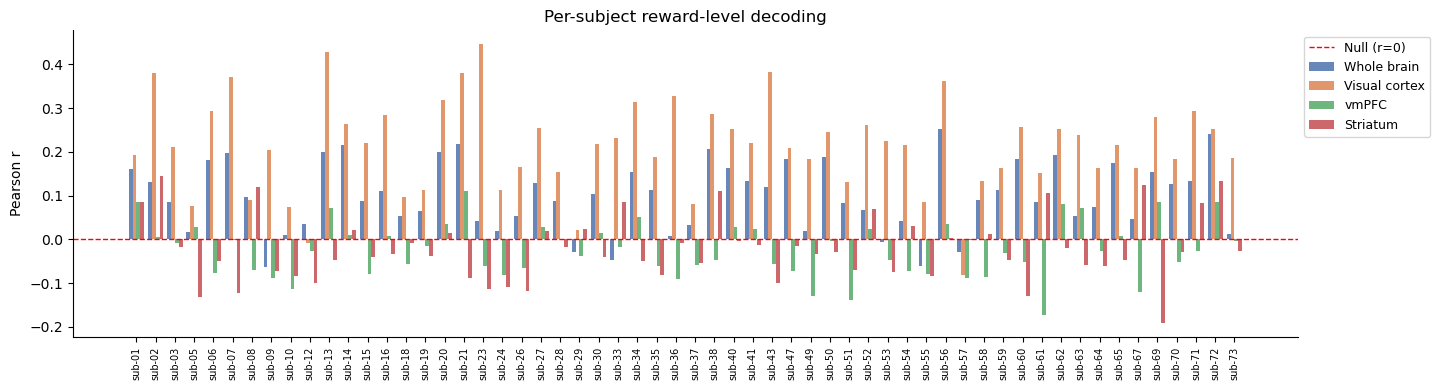

In [7]:
subjects = sorted(df["subject"].unique())
pivot = df.pivot(index="subject", columns="mask", values="r").reindex(subjects)

fig, ax = plt.subplots(figsize=(max(14, 0.25 * len(subjects)), 4))
x = np.arange(len(subjects))
n_masks = len(MASKS)
width = 0.8 / n_masks

for i, mask in enumerate(MASKS):
    if mask not in pivot.columns:
        continue
    offset = (i - (n_masks - 1) / 2) * width
    ax.bar(x + offset, pivot[mask], width=width, label=MASK_LABELS[mask], color=COLORS[mask], alpha=0.85)

ax.axhline(NULL_R, color='red', linestyle='--', linewidth=1, label='Null (r=0)')
ax.set_xticks(x)
ax.set_xticklabels([f"sub-{s}" for s in subjects], rotation=90, fontsize=7)
ax.set_ylabel("Pearson r")
ax.set_title("Per-subject reward-level decoding")
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Findings summary

n=58 (`sub-46` absent from the BBT — flagged separately, not resolved here).

| Mask | r (raw) | r (run-demeaned) | p (demeaned) |
|---|---|---|---|
| Whole brain | +0.095 | **+0.099** | 3.6e-13 \*\*\* |
| Visual cortex | +0.211 | **+0.214** | 5.4e-22 \*\*\* |
| vmPFC | −0.028 | **−0.024** | 4.5e-03 \*\* |
| Striatum | −0.028 | **−0.022** | 3.0e-02 \* (borderline) |

- **Whole-brain/visual-cortex decode reward level, genuinely.** The run-demeaning fix
  (run-centered features + scoring on run-demeaned true/predicted values) barely moved
  these two — most of their raw `r` was already real within-run signal, not the CV
  artifact — and if anything nudged them slightly *up* (wholebrain 0.081→0.099 vs. the
  very first, pre-fix run), consistent with run-centered features removing a genuine
  session-drift nuisance confound.
- **vmPFC/striatum: the fix explains most, but not all, of the negative result.** The
  between-run CV artifact (see status note above) was the dominant driver of the raw
  negative numbers, but a small residual negative `r` survives after removing it —
  clearly significant for vmPFC (p=4.5e-3), only borderline for striatum (p=0.03, would
  not survive correction for the 4 masks tested here). This reads as "no reliable
  positive within-run reward signal detected in these ROIs at this whole-ROI-average
  resolution" rather than "vmPFC/striatum anti-encode reward" — a small residual
  negative mean with wide per-subject spread (see the group r/r² plot) is exactly what a
  near-null effect measured with modest per-subject power looks like.
- **Bottom line:** this whole-ROI regression is likely too coarse to detect vmPFC/
  striatum value coding even if it's there — RidgeCV regularizes these ~120-voxel ROIs
  almost to a constant (`std(y_pred)` ~0.08 vs. ~1.2 for `y_true`), so a spatially
  localized sub-cluster signal would be invisible to a whole-ROI average. The searchlight
  analysis is the natural next step for these two regions specifically, since it can find
  a pocket of signal a whole-ROI average would wash out; whole-brain/visual-cortex
  results here already motivate spending that compute.